# C++的指针

# 1. 指针

## 1.1 指针概念

① 指针的作用：可以通过指针间接访问内存。

1. 内存编号是从0开始记录的，一般用十六进制数字表示。
2. 可以利用指针变量保存地址。
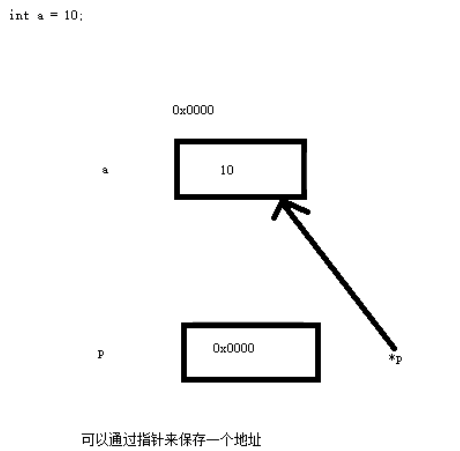

## 1.2 指针变量定义和使用

① 指针变量定义语法：数据类型 * 变量名；

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //1、定义指针
    int a = 10;

    //指针定义的语法：数据类型 * 指针变量
    int * p; //创建p为指针变量

    //让指针记录变量a的地址
    p = &a;  // &为取址符号

    cout << "a的地址为：" << &a << endl;

    cout << "指针p为：" << p << endl;  // 指针p存储的值 和变量a的地址是一样的

    //2、使用指针
    //可以通过解引用的方式来找到指针指向的内存
    //指针前加 * 代表解引用，找到指针指向的内存中的数据

    *p = 1000;  //通过*p访问内存，并修改内存的值
    cout << "a= " << a << endl;
    cout << "*p：" << *p << endl;

    system("pause");   //按任意键继续
    
    return 0;

}

运行结果：  
 - a的地址为：00FBFC78  
 - 指针p为：00FBFC78  
 - a= 1000  
 - *p：1000  
 - 请按任意键继续. . .

## 1.3 指针所占内存空间

① 在32位操作系统下，不管什么类型的指针都占4个字节的内存。

② 在64位操作系统下，不管什么类型的指针都占8个字节的内存，但是实际开发环境一般都是32位操作系统下。

x86cpu指针占4个字节的内存

x64位操作系统下指针占8个字节的内存
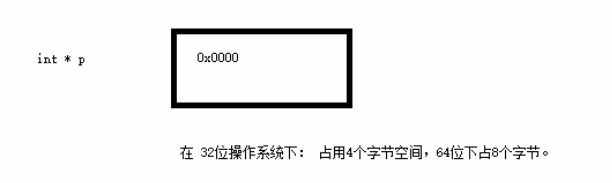

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //指针所占内存空间
    int a = 10;

    /*
    int * p; //p变量是 int * 数据类
    p = &a;

    等价于：
    int * p = &a;
    */

    int * p = &a; 

    cout << "sizeof(int * )= " << sizeof(p) << endl;
    cout << "sizeof(int * )= " << sizeof(int(*)) << endl;  
    cout << "sizeof(float * )= " << sizeof(float(*)) << endl;
    cout << "sizeof(double * )= " << sizeof(double(*)) << endl;
    cout << "sizeof(char * )= " << sizeof(char(*)) << endl;

    system("pause");   //按任意键继续

    return 0;

}

运行结果：  
 - sizeof(int * )= 4  
 - sizeof(int * )= 4  
 - sizeof(float * )= 4  
 - sizeof(double * )= 4  
 - sizeof(char * )= 4  
 - 请按任意键继续. . .

## 1.4 空指针

① 指针变量指向内存中编号为0的空间。

② 用途：初始化指针变量。

③ 空指针指向的内存是不可以访问的。

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //空指针
    //1、空指针用于给指针变量进行初始化
    int* p = NULL;

    //2、空指针是不可以进行访问的
    //0~255之间的内存编号是系统占用的，因此不可以访问。
    *p = 100;  //对空指针解引用，然后操作它，这样是报错的

    system("pause");   //按任意键继续

    return 0;

}

## 1.5 野指针

① 野指针：指针变量指向非法的内存空间。

② 野指针和空指针都不是我们申请的空间，所以不要访问。

③ 例如，创建了一个整型变量a，是申请了一个整型变量的空间，由于是申请的空间，所以可以通过指针访问它。

总结:空指针和野指针都不是我们申请的空间，因此不要访问。

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    //野指针
    int* p = (int*)0x1100; // 0x1100是一个十六进制数，int*使得十六进制数强行转换为地址。
                           // 拿指针随便指向并没有申请这个内存的访问权限的内存。

    cout << *p << endl; // 报错，地址并没有申请，你还要去访问它，就会报错

    system("pause");   

    return 0;

}

## 1.6 const修饰指针


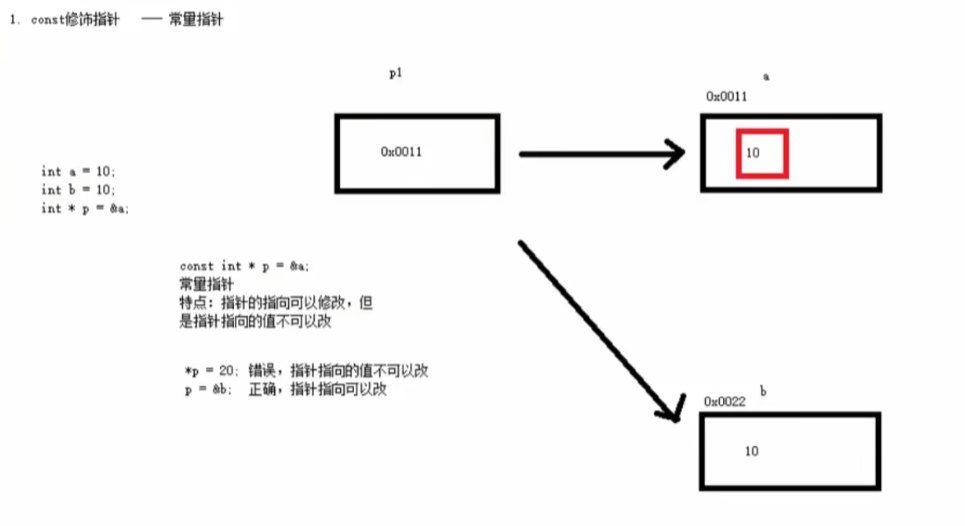

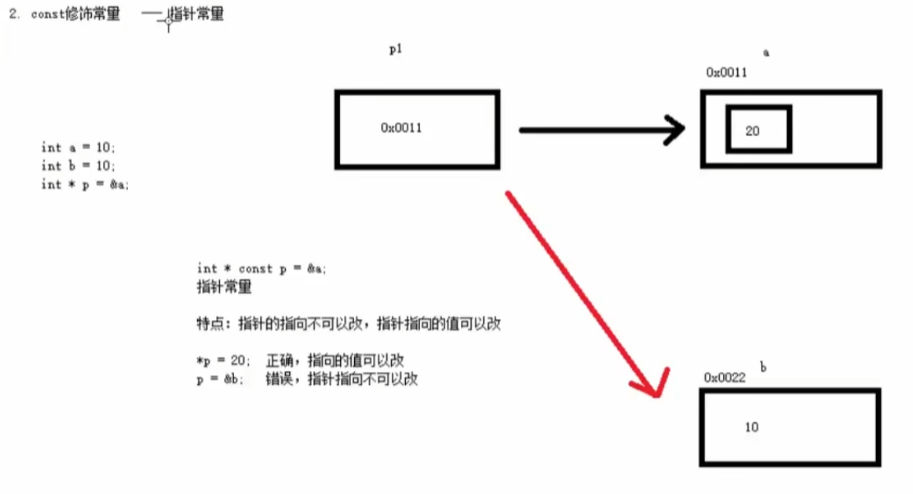
① 看const右侧紧跟着的是指针还是常量，是指针就是常量指针，是常量就是指针常量。

② 如果 const后面跟的是指针(*)，就不能做 *p=20 操作，即不能修改指针指向的值。

③ 如果const 后面跟的常量(p)，就不能做 p = &b 操作，即不能修改指针的指向。

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    
    int a = 10;
    int b = 10;

    //1、const修饰指针 常量指针
    const int* p = &a;  // const(常量) *(指针) → 常量指针 
    // *p = 20;  错误，常量指针 → 指针指向的值不可以改，指针的指向可以改
    p = &b; // 正确

    //2、const修饰指针 指针常量
    int* const p2 = &a; // *(指针)const(常量) → 指针常量
    *p2 = 100; //正确的
    p2 = &b;  //错误，指针的指向不可以改，指针指向的 值可以改

    //3、const修饰指针和常量
    const int* const p3 = &a;
    *p3 = 100;  //错误
    p3 = &b;  //错误

    system("pause");   

    return 0;

}

## 1.7 指针和数组

① 利用指针访问数组中元素。
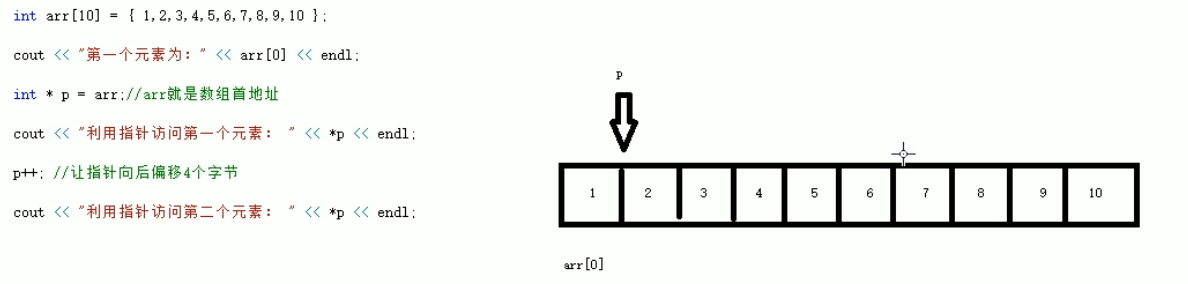

In [ ]:
#include <iostream>
using namespace std;

int main()
{
    
    //指针和数组
    //利用指针访问数组中的元素

    int arr[10] = { 1,2,3,4,5,6,7,8,9,10 };
    
    cout << "第一个元素为：" << arr[0] << endl;

    int* p = arr; //数组名arr就是数组的首地址

    cout << "利用指针访问第一个元素：" << *p << endl;

    p++;

    cout << "利用指针访问第二个元素：" << *p << endl;

    cout << "利用指针遍历数组：" << endl;

    int* p2 = arr;
    for (int i = 0; i < 10; i++) 
    {
        //cout << arr[i] << endl;
        cout << *p2 << endl;
        p2++;

    }
    system("pause");   

    return 0;

}

运行结果：  
 - 第一个元素为：1  
 - 利用指针访问第一个元素：1  
 - 利用指针访问第二个元素：2  
 - 利用指针遍历数组：  
 - 1  
 - 2  
 - 3  
 - 4  
 - 5  
 - 6  
 - 7  
 - 8  
 - 9  
 - 10  
 - 请按任意键继续. . .

## 1.8 指针和函数

值传递里面，值传递【不会】改变实参  地址传递【会】改变实参

① 利用指针作函数的参数，可以修改实参的值。

② 地址传递可以改变实参的数据，值传递不可以改变实参的值。

③ 如果不想修改实参，就用值传递，如果想修改实参，就用地址传递。

④ 代码例子中，temp的值会传递给 *p2 地址中的值，所以a、b实参的值改变了。

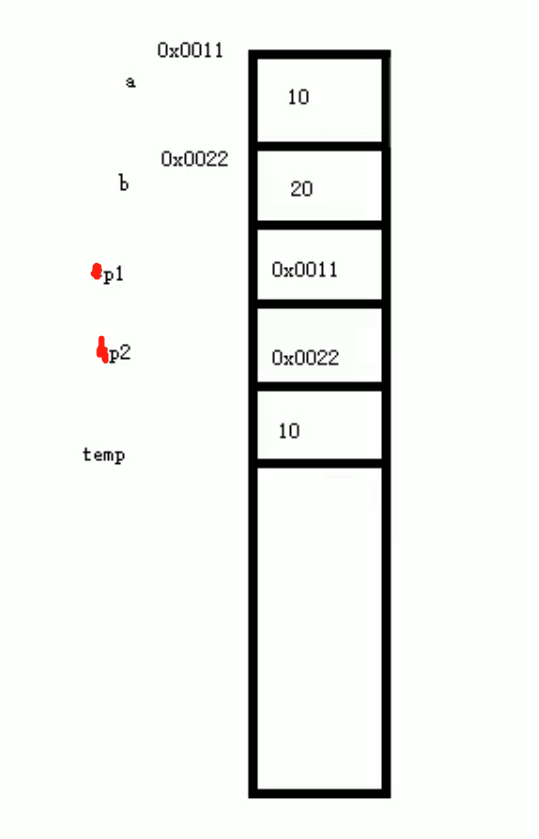

In [ ]:
#include <iostream>
using namespace std;
//fun（&a,&b）更方便，直接引用，不需要再解指针了
void swap(int* p1, int* p2)
{
    int temp = *p1;
    *p1 = *p2;
    *p2 = temp;
}

//值传递
void charge1(int x, int y) {
	int temp = x; 
	x = y;       
	y = temp;     
}

/*
void charge(int* x, int* y) {
	int temp = *x; // Store the value at address x in temp
	*x = *y;       // Assign the value at address y to address x
	*y = temp;     // Assign the value stored in temp to address y
	return;
}

调用的时候需要传入地址，如：charge(&a, &b);
*/
void charge2(int& x, int& y) {
	int temp = x; 
	x = y;       
	y = temp;     
	return;
}
/*地址传递，fun（& a, & b）更方便，直接引用，不需要再解指针了
 调用的时候需要传入变量，如：charge(a, b);
*/


int main()
{
    //指针和函数
    int a = 10;
    int b = 20;

    swap(&a, &b);

    //如果是地址传递，可以修改实参，原来 a = 10；b = 20，地址传递后 a = 20，b = 10.
    cout << "a =" << a << endl;
    cout << "b =" << b << endl;
    //如果是值传递，不可以修改实参，原来 a = 10；b = 20，值传递后 a = 10，b = 20.

    system("pause");

    return 0;

}

运行结果：
 - a =20
 - b =10
 - 请按任意键继续. . .

## 1.9 指针配合数组和函数案例

案例描述：封装一个函数，利用冒泡排序，实现对整型数字的升序排列。  

例如： int arr[10] = {4,3,6,9,1,2,10,8,7,5}

In [ ]:
#include <iostream>
using namespace std;

//冒泡排序函数
void bubbleSort(int * arr, int len)
{
    for (int i = 0; i < len - 1; i++)
    {
        for (int j = 0; j < len - i - 1; j++)
        {
            //如果j>j+1的值，交换数字
            if (arr[j] > arr[j + 1])
            {
                int temp = arr[j];
                arr[j] = arr[j + 1];
                arr[j + 1] = temp;
            }
        }
    }
}

//打印数组
void printArray(int* arr, int len)
{
    for (int i = 0; i < len; i++)
    {
        cout << arr[i] << endl;
    }
}

int main()
{
    //1、先创建数组
    int arr[10] = { 4,3,6,1,2,9,10,8,7,5 };

    //数组长度
    int len = sizeof(arr) / sizeof(arr[0]);

    //2、创建函数，实现冒泡排序
    bubbleSort(arr, len);

    //3、打印排序后的数组
    printArray(arr, len);


    system("pause");
    
    return 0;

}

运行结果：  
 - 1  
 - 2  
 - 3  
 - 4  
 - 5  
 - 6  
 - 7  
 - 8  
 - 9  
 - 10  
 - 请按任意键继续. . .